# Transformer-based Time Series Forecasting
This notebook replaces the LSTM model with a transformer encoder model for forecasting on a dataset containing multiple time series (identified by ID).

In [86]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback
from keras.optimizers import AdamW
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap
import seaborn as sns


In [87]:
print(tf.__version__)


2.19.0


# INPUTS

In [88]:
dynamic_features = ['pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30']
static_features = ['mch_elevation', 'site_enc', 'species_enc', ' year_enc', 'day_cos', 'day_sin']  # static features
features = dynamic_features 
target_column = "twd_rolling30_log"

features_to_scale = [
    'pr_rolling30', 'at_rolling30', 'ws_rolling30',
    'dp_rolling30', 'sr_rolling30', 'lr_rolling30',
    'day_cos', 'day_sin',
    'mch_elevation', 
    target_column  # target
]

SEQ_LEN = 30 # number of past time steps the model uses to make each prediction.
forec_horizon = 1  # number of future time steps to predict
my_patience = 30
my_epochs = 100
checkpoint_frequency = my_epochs //10 # Save a model checkpoint at every 10% of training
my_batch_size = 32

np.random.seed(42)

In [89]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'twd_rolling30_log']

## Load and preprocess data

In [90]:
df_ts_series = pd.read_csv('df.ts.series2.csv')
df_ts_series = df_ts_series[df_ts_series['species'] != 'Pseudotsuga menziesii']
#df_ts_series = df_ts_series[df_ts_series['at_rolling30'] >= 0]
df_ts_series 
df_ts_series['ts'].max()

'2023-12-31'

In [91]:
df_ts_series.columns
print(df_ts_series['species'].unique())

['Fagus sylvatica' 'Quercus petraea' 'Carpinus betulus' 'Corylus avellana'
 'Picea abies' 'Pinus sylvestris']


For temperatures by species, see page 5/13 of roll_avg_analysis.pdf
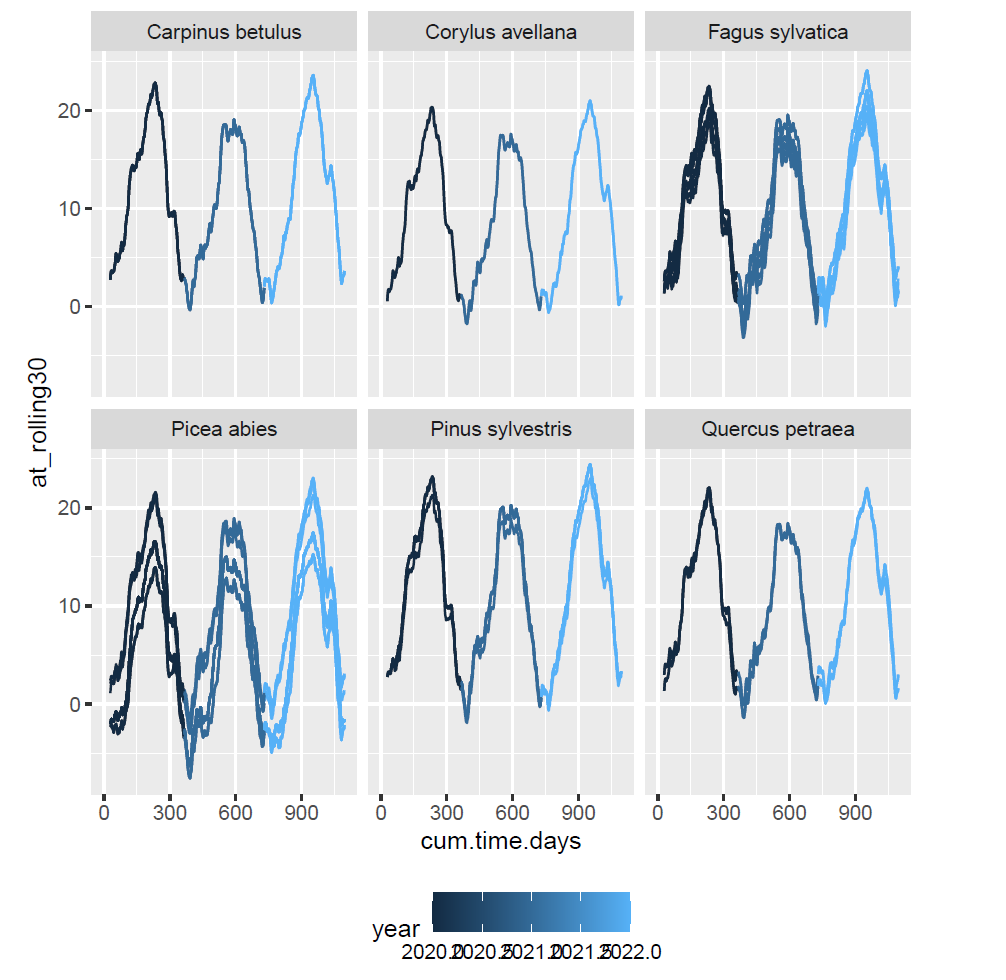

# Filter data


## Option 1: Filter rows with temperature < 0°C

In [92]:
bool_temp_below_0 = False
if bool_temp_below_0:
    # should be 5C
    below_5C = df_ts_series[df_ts_series['at_rolling30'] < 0]

    # Group by site and species and count occurrences
    low_temp_stats = below_5C.groupby(['site', 'species']).size().reset_index(name='count')

    # Show which site-species combinations had temps < 5°C
    print(low_temp_stats.sort_values(by='count', ascending=False))


In [93]:
print(df_ts_series.columns)
print("Unique months:", df_ts_series['month'].unique())

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist'],
      dtype='object')
Unique months: [ 1 12 11 10  9  8  7  6  4  5  3  2]


Option 2: Filter only measurements taken during spring and summer months (March to August)


In [94]:
bool_spring_summer = False
if bool_spring_summer:
    # Filter for spring and summer months (March to August)
    spring_summer_months = [3, 4, 5, 6, 7, 8]
    df_ts_series = df_ts_series[df_ts_series['month'].isin(spring_summer_months)]

    # Check the number of rows after filtering
    print(f"Number of rows in spring and summer: {len(df_ts_series)}")
    

In [95]:
type(df_ts_series)
print(df_ts_series.columns)
df_ts_series = df_ts_series.dropna(subset=['twd_rolling30'])
print(df_ts_series['twd_rolling30'])

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist'],
      dtype='object')
1        0.981811
2        0.484780
3        0.470288
4        0.471271
5        0.033617
           ...   
61357    0.295904
61358    0.000000
61359    0.281148
61360    0.897241
61361    0.347439
Name: twd_rolling30, Length: 56067, dtype: float64


In [96]:
df_ts_series['site'] = df_ts_series['site'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)
df_ts_series['species'] = df_ts_series['species'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)

#encoders = {}
#for col in ['site', 'species', 'year']:
#    le = LabelEncoder()
#    df_ts_series[col + '_enc'] = le.fit_transform(df_ts_series[col])
#    encoders[col] = le

# Proper encoding for categorical features
le_site = LabelEncoder()
le_species = LabelEncoder()
le_year = LabelEncoder()

df_ts_series['site_enc'] = le_site.fit_transform(df_ts_series['site'])
df_ts_series['species_enc'] = le_species.fit_transform(df_ts_series['species'])
df_ts_series['year_enc'] = le_year.fit_transform(df_ts_series['year'])

In [97]:
df_ts_series

,Unnamed: 0,site,tree.id,ts,twd,pr,at,ws,dp,sr,...,site_easting,site_northing,mch_ind_closest,mch_easting,mch_northing,mch_elevation,mch_site_eucldist,site_enc,species_enc,year_enc
1,2,Bachtel-Forest,1,2022-01-25,1.472441,6.317190e-07,-0.877331,1.446561,-4.169493,87.166218,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,2
2,3,Bachtel-Forest,1,2021-12-30,0.000000,1.354897e-01,8.044978,1.798020,6.588012,10.034880,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,1
3,4,Bachtel-Forest,1,2021-12-04,0.102781,8.992752e-01,0.425184,3.472994,-0.203040,14.275745,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,1
4,5,Bachtel-Forest,1,2023-12-29,1.806872,2.466016e-01,5.700417,2.149112,2.415436,34.092931,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,3
5,6,Bachtel-Forest,1,2023-12-03,0.223431,1.555906e-02,-5.941142,2.207970,-7.932864,71.131448,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61357,61358,Sihlwald-Forest,42,2022-01-27,0.552742,7.802187e-02,-1.438328,3.021568,-3.402347,75.874154,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,2
61358,61359,Sihlwald-Forest,42,2020-08-08,0.000000,5.519638e-07,21.852218,1.811116,15.480772,274.571957,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,0
61359,61360,Sihlwald-Forest,42,2021-12-31,0.329179,4.944194e-07,7.580756,3.141046,5.238666,50.878425,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,1
61360,61361,Sihlwald-Forest,42,2021-04-14,0.984201,1.427069e-03,1.823537,3.916790,-4.426657,222.192110,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,1


You map each day to a point on a circle. This way:

- Day 1 and Day 366 end up very close on the circle

- The relationship between days is smooth and continuous

- Models (especially linear or neural nets) can better learn time patterns

In [98]:
tree_min_max = df_ts_series.groupby('tree.id')['ts'].agg(['min', 'max']).reset_index()
print(tree_min_max)

    tree.id         min         max
0         1  2020-01-30  2023-12-30
1         2  2020-01-30  2023-12-30
2         3  2020-01-30  2023-12-30
3         4  2020-01-30  2023-12-30
4         5  2020-01-30  2023-12-30
5         6  2020-01-30  2023-12-30
6         7  2020-01-30  2023-12-30
7         8  2020-01-30  2023-12-30
8         9  2020-01-30  2023-12-30
9        10  2020-01-30  2023-12-30
10       11  2020-01-30  2023-07-19
11       12  2020-01-30  2023-12-30
12       13  2020-01-30  2023-12-30
13       14  2020-01-30  2023-12-30
14       15  2020-01-30  2023-12-28
15       16  2020-01-30  2023-12-30
16       17  2020-01-30  2023-12-30
17       18  2020-01-30  2023-06-14
18       19  2020-01-30  2023-12-30
19       22  2020-01-30  2023-12-30
20       23  2020-01-30  2023-12-30
21       24  2020-01-30  2023-12-30
22       25  2020-01-30  2023-12-30
23       26  2020-01-30  2023-12-30
24       27  2020-01-30  2023-12-30
25       28  2020-01-30  2023-12-30
26       29  2020-01-30  202

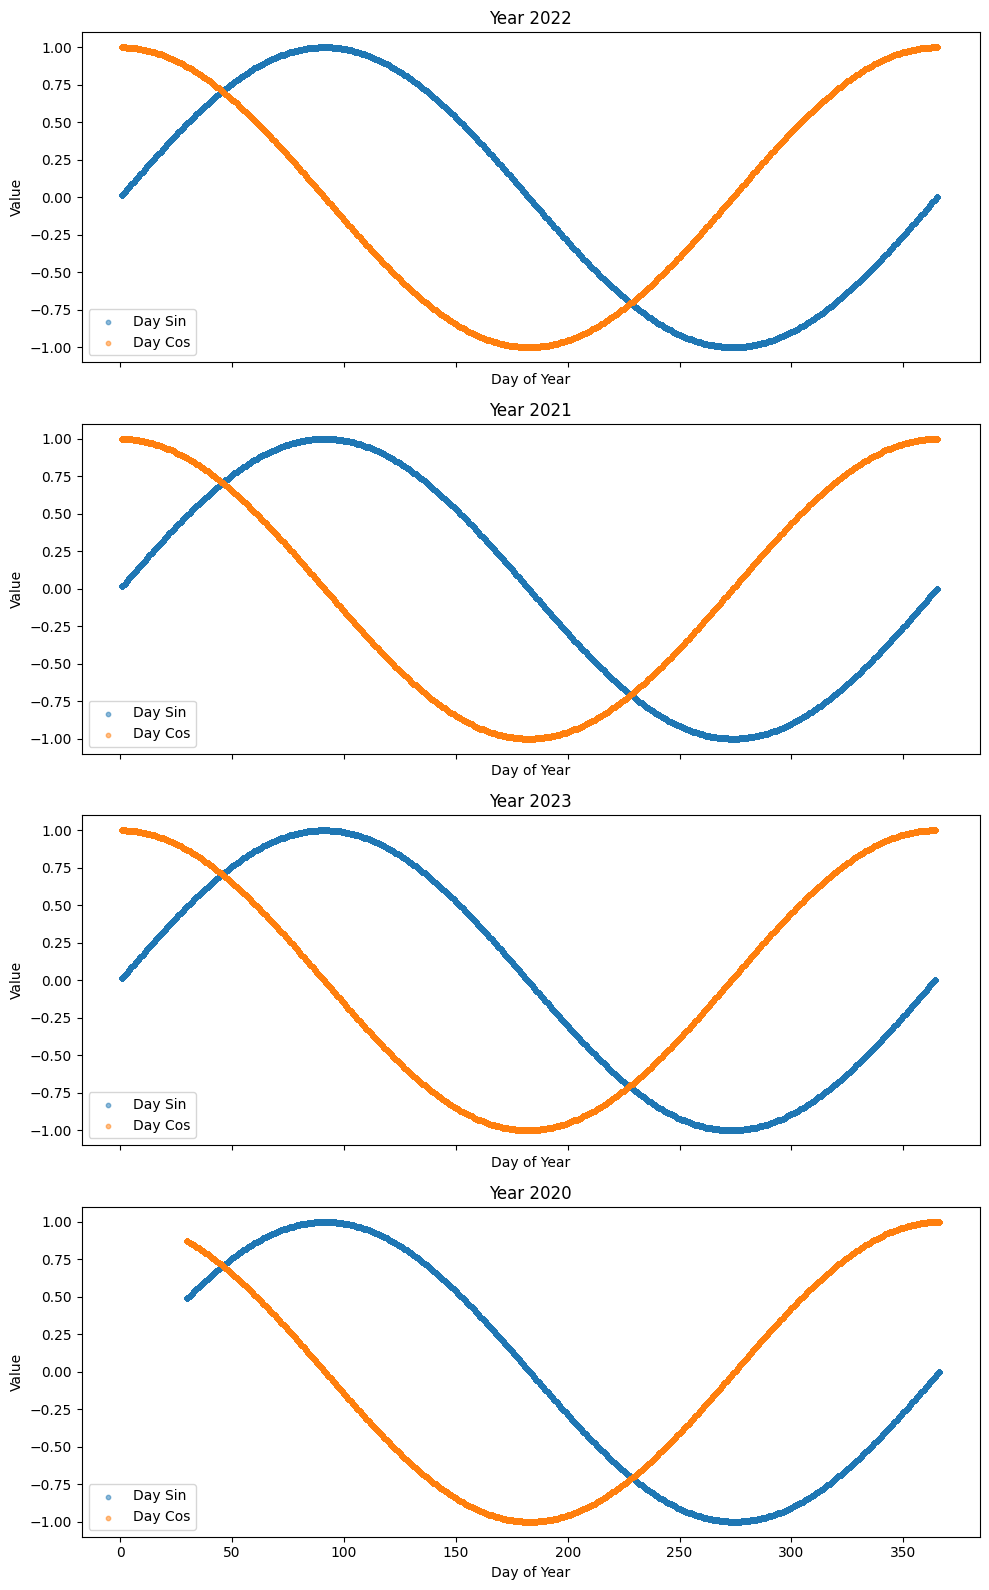

In [99]:
# change column name day.of.year to day_of_year, as numeric
df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)


# Compute number of days per year (handles leap years)
days_per_year = df_ts_series.groupby('year')['day_of_year'].max().to_dict()

df_ts_series['days_in_year'] = df_ts_series['year'].map(days_per_year)
df_ts_series['day_sin'] = np.sin(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])
df_ts_series['day_cos'] = np.cos(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])

years = df_ts_series['year'].unique()
n_years = len(years)
nrows = 4  # Number of rows in the subplot grid
ncols = 1  # Number of columns in the subplot grid
# plot day_sin and day_cos as points (not lines)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows), sharex=True, sharey=True)

for ax, year in zip(axes.flat, years):
    group = df_ts_series[df_ts_series['year'] == year]
    ax.scatter(group['day_of_year'], group['day_sin'], label='Day Sin', alpha=0.5, s=10)
    ax.scatter(group['day_of_year'], group['day_cos'], label='Day Cos', alpha=0.5, s=10)
    ax.set_title(f'Year {year}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Value')
    ax.legend()

# Hide any unused subplots
for i in range(n_years, nrows * ncols):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()

In [100]:
days_per_year

{'2020': 366, '2021': 365, '2022': 365, '2023': 364}

In [101]:
df_ts_series.groupby('year')['day_of_year'].min().to_dict()


{'2020': 30, '2021': 1, '2022': 1, '2023': 1}

2020 starts at day 30 because of the rolling average. The first 30 days are not available in the dataset.

In [102]:
print(df_ts_series.columns)
df_ts_series["species_enc"]
# Assume you have these columns
print(df_ts_series['mch_elevation'])
print(df_ts_series['site'] )
print(df_ts_series['site_enc'] )


Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist', 'site_enc', 'species_enc', 'year_enc',
       'days_in_year', 'day_sin', 'day_cos'],
      dtype='object')
1        882.140575
2        882.140575
3        882.140575
4        882.140575
5        882.140575
            ...    
61357    722.265575
61358    722.265575
61359    722.265575
61360    722.265575
61361    722.26

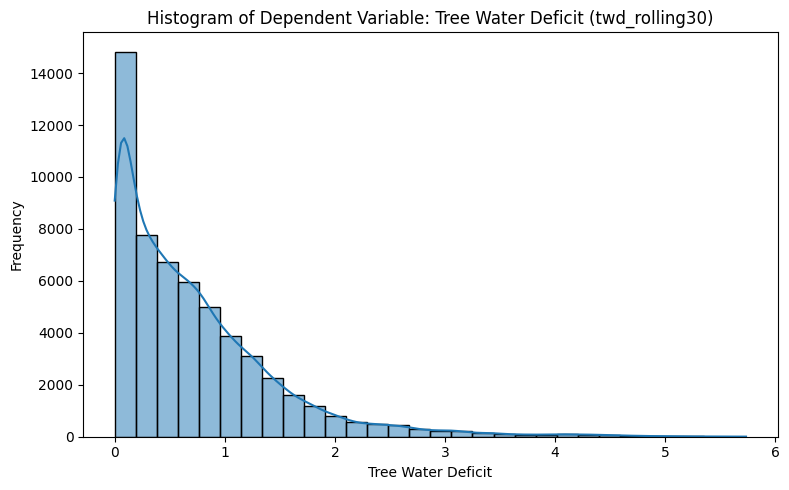

In [103]:
plt.figure(figsize=(8, 5))
sns.histplot(df_ts_series['twd_rolling30'], bins=30, kde=True)
plt.title('Histogram of Dependent Variable: Tree Water Deficit (twd_rolling30)')
plt.xlabel('Tree Water Deficit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

We have a Severely skewed target distribution
Most Tree Water Deficit (TWD) values are near zero, with a long tail of rare high values.

If we do not normalize, MSE is dominated by frequent low values:
➔ The model prefers to predict near-zero to minimize overall loss.
➔ Peaks are systematically underpredicted.

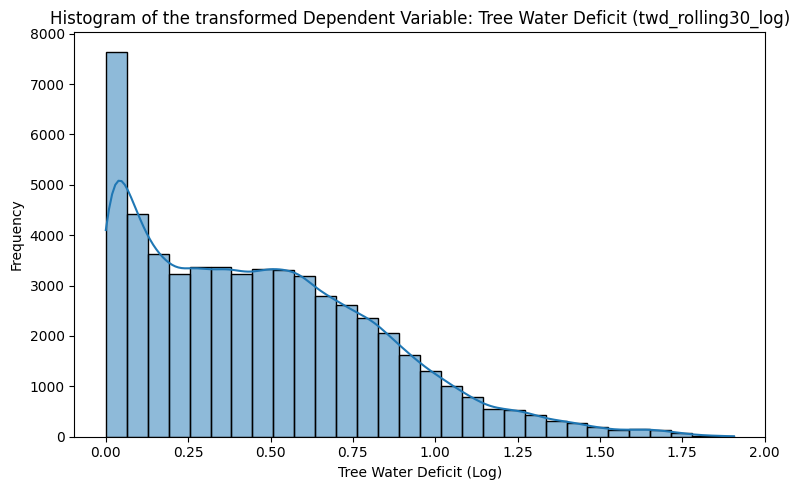

In [104]:
df_ts_series['twd_rolling30_log'] = np.log1p(df_ts_series['twd_rolling30'])

plt.figure(figsize=(8, 5))
sns.histplot(df_ts_series['twd_rolling30_log'], bins=30, kde=True)
plt.title('Histogram of the transformed Dependent Variable: Tree Water Deficit (twd_rolling30_log)')
plt.xlabel('Tree Water Deficit (Log)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [105]:
# Initialize dictionary to store scalers
scalers = {}

# Scale each feature individually
for col in features_to_scale:
    scaler = MinMaxScaler()
    df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
    scalers[col] = scaler


In [106]:
print(df_ts_series.columns)

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist', 'site_enc', 'species_enc', 'year_enc',
       'days_in_year', 'day_sin', 'day_cos', 'twd_rolling30_log',
       'pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled',
       'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled',
       'day_cos_scaled', 'day_sin_scaled', 'mch_elevation_scaled'

## Create input sequences

In [107]:

# Create list of scaled dynamic features
dynamic_scaled_features = [f"{feat}_scaled" for feat in dynamic_features]

static_scaled_features = ['site_enc', 'species_enc', 'mch_elevation_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled' ]
target_scaled = target_column + '_scaled'
print(dynamic_scaled_features)
print(static_scaled_features)
print(target_scaled)


['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled']
['site_enc', 'species_enc', 'mch_elevation_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled']
twd_rolling30_log_scaled


In [108]:

def create_sequences(df, seq_len, forecast_horizon=1):
    X_seq, X_static, y, meta = [], [], [], []
    for series_id, group in df.groupby('tree.id'):
        if len(group) < seq_len + forecast_horizon:
            continue
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            window = group.iloc[i:i+seq_len]
            target_window = group.iloc[i+seq_len:i+seq_len+forecast_horizon]
            
            X_seq.append(window[dynamic_scaled_features].values)
            static = group.iloc[i][static_scaled_features].values
            X_static.append(static)
            y.append(target_window[target_scaled].values)

        
            meta.append({
                'tree_id': series_id,
                'site': group.iloc[i]['site'],
                'species': group.iloc[i]['species'],
                'year': group.iloc[i]['year'], 
                'timestamps': window['cum.time.days'].tolist(),  # assuming your timestamp column is 'date',
                'day_sin': group.iloc[i]['day_sin'],
                'day_cos': group.iloc[i]['day_cos'],
                'start_index': window.index[0]
            })
    
    return np.array(X_seq), np.array(X_static), np.array(y), meta


Why the test set should be temporally after the training set
If your model sees future data during training, it will:
1. Leak information it wouldn’t have in reality.
2. Artificially inflate performance metrics.
3. Fail in production, where only past data is available to forecast the future.

In [109]:
# --- Split by time for each tree ---

# Set the percentage of data to use for the test set (e.g., 20%)
test_percent = 0.2  # Change this value as needed

train_indices, test_indices = [], []

for tree_id, group in df_ts_series.groupby('tree.id'):
    group_sorted = group.sort_values('cum.time.days')
    n = len(group_sorted)
    split_point = int(n * (1 - test_percent))
    train_indices.extend(group_sorted.index[:split_point])
    test_indices.extend(group_sorted.index[split_point:])

df_train = df_ts_series.loc[train_indices].reset_index(drop=True)
df_test = df_ts_series.loc[test_indices].reset_index(drop=True)

# 2. Generate sequences separately for train and test sets
X_seq_train, X_static_train, y_train, meta_train = create_sequences(df=df_train, seq_len=SEQ_LEN, forecast_horizon=forec_horizon)
X_seq_test, X_static_test, y_test, meta_test = create_sequences(df=df_test, seq_len=SEQ_LEN, forecast_horizon=forec_horizon)

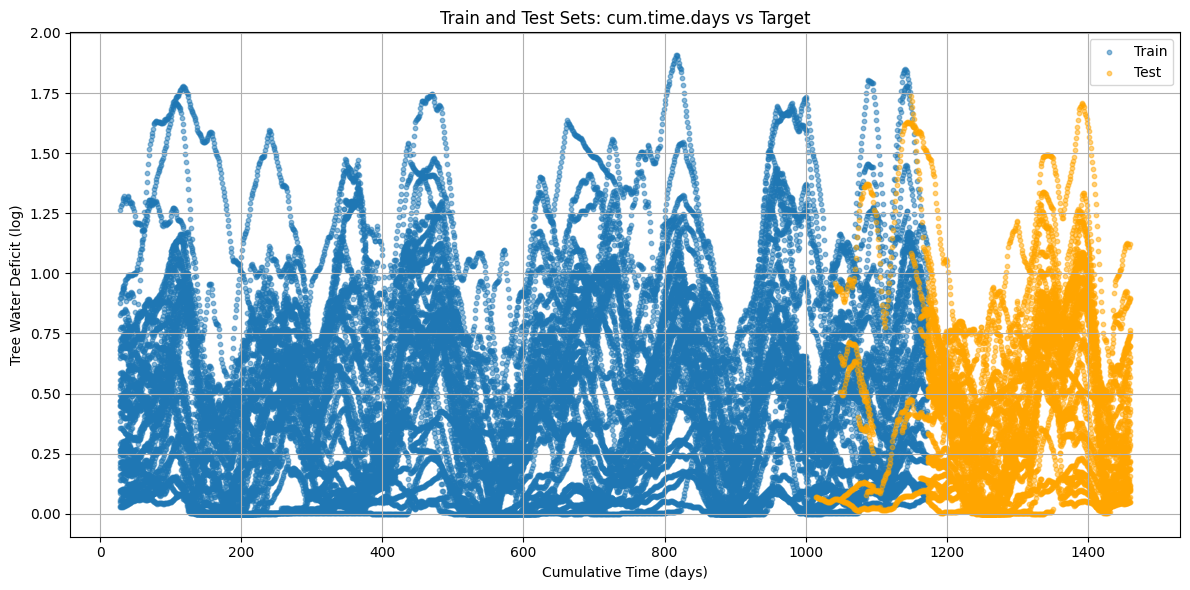

In [110]:
plt.figure(figsize=(12, 6))
plt.scatter(df_train['cum.time.days'], df_train[target_column], label='Train', alpha=0.5, s=10)
plt.scatter(df_test['cum.time.days'], df_test[target_column], label='Test', alpha=0.5, s=10, color='orange')
plt.xlabel('Cumulative Time (days)')
plt.ylabel('Tree Water Deficit (log)')
plt.title('Train and Test Sets: cum.time.days vs Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
tree_info = meta_test[2] # example
print(tree_info)

{'tree_id': 1, 'site': 'Bachtel-Forest', 'species': 'Fagus sylvatica', 'year': '2023', 'timestamps': [1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204], 'day_sin': np.float64(0.9820275556534303), 'day_cos': np.float64(0.1887375954529167), 'start_index': np.int64(2)}


In [115]:

max_site_enc = int(df_ts_series['site_enc'].max())
print("Max site_enc:", max_site_enc)
max_species_enc = int(df_ts_series['species_enc'].max())
print("Max species_enc:", max_species_enc)
max_year_enc = int(df_ts_series['year_enc'].max())
print("Max year_enc:", max_year_enc)
print(df_ts_series['year_enc'].unique())


Max site_enc: 18
Max species_enc: 5
Max year_enc: 3
[2 1 3 0]


## Define transformer block

R² is not differentiable in a stable way, Use R² only as a monitoring metric during training. R2 pertains to the whole batch, 

If your model predicts forecast_horizon = 7 future steps (i.e., y_pred.shape = (batch_size, 7)), you can compute R² per output like this:

In [116]:
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(x.shape[-1])(ff_output)
    return LayerNormalization(epsilon=1e-6)(x + ff_output)


In [117]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

In [118]:
def r2_score_per_timestep(y_true, y_pred):
    # Compute R² for each time step separately and return the average
    
    diff = y_true - y_pred
    #tf.print("Shape of y_true:", tf.shape(y_true)) # [31 1]
    # tf.print("Shape of y_pred:", tf.shape(y_pred))  # [31 1]
    
    ss_res = K.sum(K.square(diff), axis=0)
    ss_tot = K.sum(K.square(y_true - K.mean(y_true, axis=0)), axis=0)
    r2 = 1 - (ss_res / (ss_tot + K.epsilon()))
    return K.mean(r2)

In [119]:
# Define your species weights (example: all 1.0)#
# species_weights = np.ones(df_ts_series['species_enc'].max() + 1)
species_counts = df_ts_series['species_enc'].value_counts().sort_index().values
species_weights = np.array([1 / count for count in species_counts])
species_weights /= np.sum(species_weights) / len(species_weights)  # normalize to mean 1

# using mean
def weighted_mse_wrapper(species_weights):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true_values = y_true[:, :-1]
        species_ids = tf.cast(y_true[:, -1], tf.int32)
        mse = tf.square(y_true_values - y_pred) # Standard squared error between predictions and true values.
        # tf.gather() looks up the weight for each sample based on its species ID.
        # weights will have the same length as the batch size, each corresponding to the sample’s species.
        weights = tf.gather(tf.constant(species_weights, dtype=tf.float32), species_ids)
        return tf.reduce_mean(mse * weights)
    return loss

# using quantile loss
def weighted_quantile_loss_wrapper(species_weights, q=0.5):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true_values = y_true[:, :-1]
        species_ids = tf.cast(y_true[:, -1], tf.int32)

        # Quantile loss (pinball loss)
        error = y_true_values - y_pred
        quantile_loss = tf.maximum(q * error, (q - 1) * error)

        # Species weights
        weights = tf.gather(tf.constant(species_weights, dtype=tf.float32), species_ids)

        # Final weighted quantile loss
        return tf.reduce_mean(quantile_loss * weights)
    return loss

In [120]:
print(species_counts)
for i, weight in enumerate(species_weights):
    print(f"species_enc: {i}, species: {le_species.inverse_transform([i])[0]}, weight: {weight}")

[ 5724  2862 14154 21040  6563  5724]
species_enc: 0, species: Carpinus betulus, weight: 1.0813491776149198
species_enc: 1, species: Corylus avellana, weight: 2.1626983552298396
species_enc: 2, species: Fagus sylvatica, weight: 0.43730695864545716
species_enc: 3, species: Picea abies, weight: 0.29418453862489546
species_enc: 4, species: Pinus sylvestris, weight: 0.943111792269968
species_enc: 5, species: Quercus petraea, weight: 1.0813491776149198


## Build and compile the transformer model

In [121]:
n_features = X_seq_test.shape[-1]
print(n_features)

# Inputs
seq_input = Input(shape=(SEQ_LEN, n_features), name='seq_input')
site_input = Input(shape=(1,), name='site')
species_input = Input(shape=(1,), name='species')
mch_input = Input(shape=(1,), name='mch_input')
year_input = Input(shape=(1,), name='year_input')
day_sin_input = Input(shape=(1,), name='day_sin')
day_cos_input = Input(shape=(1,), name='day_cos')

# Static embeddings
# Always set input_dim = max value in column + 1.
site_emb = Embedding(input_dim= 19, output_dim=2)(site_input)
species_emb = Embedding(input_dim= 6, output_dim=4)(species_input)
site_vec = Flatten()(site_emb)
species_vec = Flatten()(species_emb)

# Positional encoding
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
pos_embedding = Embedding(input_dim=SEQ_LEN, output_dim=n_features)(positions)
pos_encoded = seq_input + pos_embedding

# Transformer block
# temporal feature learning capacity
# More transformer blocks stacked enhances temporal pattern learning.
x = transformer_block(pos_encoded, head_size=32, num_heads=4, ff_dim=128)
x = Dropout(0.2)(x)
x = transformer_block(x, head_size=32, num_heads=4, ff_dim=128)
x = Dropout(0.2)(x)
x = GlobalAveragePooling1D()(x)

# Combine with static
static_vec = Concatenate()([site_vec, species_vec, mch_input, year_input, day_sin_input, day_cos_input])
combined = Concatenate()([x, static_vec])

# Output, use RELU or softplus to avoid negative values
# forecast of the next time step (1-step-ahead).
output = Dense(forec_horizon, activation='softplus')(combined)

# weight_decay=0 disables the benefits of AdamW
# learning rate is a scalar multiplier for the computed gradients.
#Typical values, For Adam or AdamW optimizers:
#Common: 1e-3 (0.001)
#Smaller for fine-tuning or transformers: 1e-4 (0.0001) or 1e-5 (0.00001)
optimizer = AdamW(learning_rate=1e-6, weight_decay=1e-4)
model = Model(inputs=[seq_input, mch_input, site_input, species_input, year_input, day_sin_input, day_cos_input], outputs=output)
model.compile(
    optimizer=optimizer,
    # loss='mse', # Still use MSE or MAE for training
    #loss = weighted_mse_wrapper(species_weights),
    loss = weighted_quantile_loss_wrapper(species_weights, q=0.7),
    #loss = quantile_loss(0.5),
    metrics=[r2_score_per_timestep]
    )  # You may consider 'mae' for multi-step
model.summary()


6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 6)     │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 6)     │      3,462 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 6)     │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 6)     │         12 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │        896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 6)     │        774 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 6)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 6)     │         12 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 6)     │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 6)     │      3,462 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 6)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 6)     │         12 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │        896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 6)     │        774 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 6)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ site (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 6)     │         12 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 10,391 (40.59 KB)

 Trainable params: 10,391 (40.59 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [122]:
X_static_train

array([[np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7462740339769321),
        np.float64(0.9351426205150777)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7537075466469227),
        np.float64(0.930850879974034)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7610662905384125),
        np.float64(0.9264321657010799)],
       ...,
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.1691826908788605),
        np.float64(0.874913200602284)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.1756852194825091),
        np.float64(0.8805521293303871)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.18228384955491123),
        np.float64(0.886078292249582)]], dtype=object)

In [123]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'twd_rolling30_log']

In [124]:
class PeriodicCheckpoint(Callback):
    def __init__(self, save_path, frequency):
        super().__init__()
        self.save_path = save_path
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.frequency == 0:
            filepath = os.path.join(self.save_path, f"model_epoch_{epoch+1}.h5")
            self.model.save(filepath)
            print(f"✅ Saved model at epoch {epoch + 1} to {filepath}")

     

In [125]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_callback = PeriodicCheckpoint(save_path=checkpoint_dir, frequency=checkpoint_frequency)       

In [126]:
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience= my_patience,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

In [127]:
X_static_train

array([[np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7462740339769321),
        np.float64(0.9351426205150777)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7537075466469227),
        np.float64(0.930850879974034)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7610662905384125),
        np.float64(0.9264321657010799)],
       ...,
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.1691826908788605),
        np.float64(0.874913200602284)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.1756852194825091),
        np.float64(0.8805521293303871)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.18228384955491123),
        np.float64(0.886078292249582)]], dtype=object)

In [128]:
# For training
y_train_with_species = np.concatenate([
    y_train.astype(np.float32), 
    X_static_train[:, 1].reshape(-1, 1).astype(np.float32)  # species_enc is column 1
], axis=1)

# For testing
y_test_with_species = np.concatenate([
    y_test.astype(np.float32), 
    X_static_test[:, 1].reshape(-1, 1).astype(np.float32)
], axis=1)

For a non-random validation split for time series forecasting, it should be temporal. This means the validation set should contain data from a later time period than the training set, to mimic real-world forecasting and avoid data leakage.

In [129]:
# Temporal validation split for each tree in training set
val_indices = []
train_indices_actual = []

for tree_id, group in df_train.groupby('tree.id'):
    group_sorted = group.sort_values('cum.time.days')
    n = len(group_sorted)
    split_point = int(n * 0.84)  # 70% train, 30% val for each tree
    train_indices_actual.extend(group_sorted.index[:split_point])
    val_indices.extend(group_sorted.index[split_point:])

# Use start_index from meta_train to select sequences
seq_start_indices = [m['start_index'] for m in meta_train]

train_mask = np.isin(seq_start_indices, train_indices_actual)
val_mask = np.isin(seq_start_indices, val_indices)

X_seq_train_actual = X_seq_train[train_mask]
X_static_train_actual = X_static_train[train_mask]
y_train_actual = y_train_with_species[train_mask]

X_seq_val = X_seq_train[val_mask]
X_static_val = X_static_train[val_mask]
y_val = y_train_with_species[val_mask]

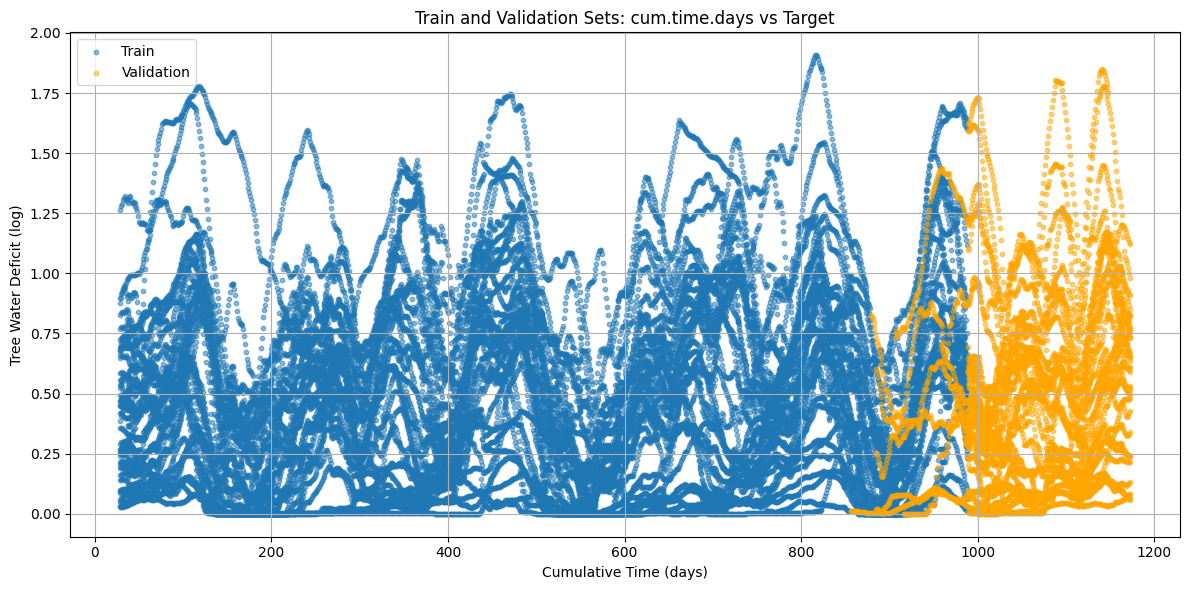

In [130]:
plt.figure(figsize=(12, 6))
plt.scatter(df_train.loc[train_indices_actual, 'cum.time.days'], df_train.loc[train_indices_actual, target_column], label='Train', alpha=0.5, s=10)
plt.scatter(df_train.loc[val_indices, 'cum.time.days'], df_train.loc[val_indices, target_column], label='Validation', alpha=0.5, s=10, color='orange')
plt.xlabel('Cumulative Time (days)')
plt.ylabel('Tree Water Deficit (log)')
plt.title('Train and Validation Sets: cum.time.days vs Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [131]:
fit_model = True  # Set to False to load the model instead of fitting

if not fit_model and os.path.exists("transformer_model.h5"):
    model = tf.keras.models.load_model("transformer_model.h5", custom_objects={"r2_score_per_timestep": r2_score_per_timestep})
    history = None
else:
    # Model will be fit below
    
    history = model.fit(
        {
            'seq_input': X_seq_train_actual,
            'mch_input': X_static_train_actual[:, 2].astype(np.float32),
            'site': X_static_train_actual[:, 0].astype(np.int32),
            'species': X_static_train_actual[:, 1].astype(np.int32),
            'year_input': X_static_train_actual[:, 3].astype(np.int32),
            'day_sin': X_static_train_actual[:, 4].astype(np.float32),
            'day_cos': X_static_train_actual[:, 5].astype(np.float32),
        },
        y_train_actual,
        validation_data=(
            {
                'seq_input': X_seq_val,
                'mch_input': X_static_val[:, 2].astype(np.float32),
                'site': X_static_val[:, 0].astype(np.int32),
                'species': X_static_val[:, 1].astype(np.int32),
                'year_input': X_static_val[:, 3].astype(np.int32),
                'day_sin': X_static_val[:, 4].astype(np.float32),
                'day_cos': X_static_val[:, 5].astype(np.float32),
            },
            y_val
        ),
        epochs=my_epochs,
        batch_size=my_batch_size,
        callbacks=[early_stopping, checkpoint_callback]
    )
    # Save the model after training
    model.save("transformer_model.h5")

Epoch 1/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - loss: 0.1313 - r2_score_per_timestep: -8.3574 - val_loss: 0.1047 - val_r2_score_per_timestep: -864972736.0000
Epoch 2/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0973 - r2_score_per_timestep: -5.0898 - val_loss: 0.0810 - val_r2_score_per_timestep: -960770944.0000
Epoch 3/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0783 - r2_score_per_timestep: -3.3785 - val_loss: 0.0667 - val_r2_score_per_timestep: -1034451776.0000
Epoch 4/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0705 - r2_score_per_timestep: -2.6429 - val_loss: 0.0600 - val_r2_score_per_timestep: -1079977984.0000
Epoch 5/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0657 - r2_score_per_timestep: -2.3261 - val_loss: 0.0567 - val_r2_score_per_timestep: -1106442240.0000
Epoch 6/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.0634 - r2_score_per_timestep: -2.1571 - val_loss: 0.0550 - val_r2_score_per_timestep:

✅ Saved model at epoch 10 to checkpoints\model_epoch_10.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.0572 - r2_score_per_timestep: -2.0165 - val_loss: 0.0523 - val_r2_score_per_timestep: -1135887616.0000
Epoch 11/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0563 - r2_score_per_timestep: -1.9908 - val_loss: 0.0521 - val_r2_score_per_timestep: -1138818048.0000
Epoch 12/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0550 - r2_score_per_timestep: -1.9923 - val_loss: 0.0518 - val_r2_score_per_timestep: -1139216384.0000
Epoch 13/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0545 - r2_score_per_timestep: -2.0353 - val_loss: 0.0517 - val_r2_score_per_timestep: -1141179520.0000
Epoch 14/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0544 - r2_score_per_timestep: -1.9655 - val_loss: 0.0515 - val_r2_score_per_timestep: -1141836288.0000
Epoch 15/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0540 - r2_score_per_timestep: -

✅ Saved model at epoch 20 to checkpoints\model_epoch_20.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.0508 - r2_score_per_timestep: -1.9329 - val_loss: 0.0512 - val_r2_score_per_timestep: -1148416896.0000
Epoch 21/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0504 - r2_score_per_timestep: -1.9258 - val_loss: 0.0509 - val_r2_score_per_timestep: -1148183808.0000
Epoch 22/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 0.0503 - r2_score_per_timestep: -1.9234 - val_loss: 0.0509 - val_r2_score_per_timestep: -1149097344.0000
Epoch 23/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 0.0494 - r2_score_per_timestep: -1.9017 - val_loss: 0.0506 - val_r2_score_per_timestep: -1148831744.0000
Epoch 24/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0488 - r2_score_per_timestep: -1.8752 - val_loss: 0.0507 - val_r2_score_per_timestep: -1150653184.0000
Epoch 25/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0488 - r2_score_per_timestep: -

✅ Saved model at epoch 30 to checkpoints\model_epoch_30.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0470 - r2_score_per_timestep: -1.8152 - val_loss: 0.0494 - val_r2_score_per_timestep: -1149120512.0000
Epoch 31/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0466 - r2_score_per_timestep: -1.8044 - val_loss: 0.0492 - val_r2_score_per_timestep: -1148911232.0000
Epoch 32/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - loss: 0.0460 - r2_score_per_timestep: -1.7918 - val_loss: 0.0491 - val_r2_score_per_timestep: -1149134976.0000
Epoch 33/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0454 - r2_score_per_timestep: -1.8115 - val_loss: 0.0488 - val_r2_score_per_timestep: -1148003840.0000
Epoch 34/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0455 - r2_score_per_timestep: -1.8154 - val_loss: 0.0487 - val_r2_score_per_timestep: -1147943680.0000
Epoch 35/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0451 - r2_score_per_timestep: -

✅ Saved model at epoch 40 to checkpoints\model_epoch_40.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0442 - r2_score_per_timestep: -1.7496 - val_loss: 0.0475 - val_r2_score_per_timestep: -1143479936.0000
Epoch 41/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0441 - r2_score_per_timestep: -1.8156 - val_loss: 0.0477 - val_r2_score_per_timestep: -1144600064.0000
Epoch 42/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - loss: 0.0442 - r2_score_per_timestep: -1.7331 - val_loss: 0.0476 - val_r2_score_per_timestep: -1144092544.0000
Epoch 43/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0445 - r2_score_per_timestep: -1.7654 - val_loss: 0.0474 - val_r2_score_per_timestep: -1143374336.0000
Epoch 44/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0442 - r2_score_per_timestep: -1.6929 - val_loss: 0.0473 - val_r2_score_per_timestep: -1142938112.0000
Epoch 45/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0443 - r2_score_per_timestep: -

...

✅ Saved model at epoch 60 to checkpoints\model_epoch_60.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0429 - r2_score_per_timestep: -1.7244 - val_loss: 0.0457 - val_r2_score_per_timestep: -1136569856.0000
Epoch 61/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - loss: 0.0425 - r2_score_per_timestep: -1.7055 - val_loss: 0.0458 - val_r2_score_per_timestep: -1137353600.0000
Epoch 62/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0423 - r2_score_per_timestep: -1.6973 - val_loss: 0.0460 - val_r2_score_per_timestep: -1138310272.0000
Epoch 63/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0421 - r2_score_per_timestep: -1.7279 - val_loss: 0.0457 - val_r2_score_per_timestep: -1136786944.0000
Epoch 64/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.0421 - r2_score_per_timestep: -1.6901 - val_loss: 0.0455 - val_r2_score_per_timestep: -1136190080.0000
Epoch 65/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - loss: 0.0424 - r2_score_per_timestep: -

✅ Saved model at epoch 70 to checkpoints\model_epoch_70.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 0.0415 - r2_score_per_timestep: -1.7039 - val_loss: 0.0454 - val_r2_score_per_timestep: -1136041216.0000
Epoch 71/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0419 - r2_score_per_timestep: -1.7305 - val_loss: 0.0451 - val_r2_score_per_timestep: -1134482688.0000
Epoch 72/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0411 - r2_score_per_timestep: -1.7017 - val_loss: 0.0450 - val_r2_score_per_timestep: -1134418944.0000
Epoch 73/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0416 - r2_score_per_timestep: -1.6820 - val_loss: 0.0451 - val_r2_score_per_timestep: -1134590336.0000
Epoch 74/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.0419 - r2_score_per_timestep: -1.7236 - val_loss: 0.0451 - val_r2_score_per_timestep: -1134739584.0000
Epoch 75/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 0.0417 - r2_score_per_timestep: -

✅ Saved model at epoch 80 to checkpoints\model_epoch_80.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0410 - r2_score_per_timestep: -1.7201 - val_loss: 0.0445 - val_r2_score_per_timestep: -1132063232.0000
Epoch 81/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0407 - r2_score_per_timestep: -1.7109 - val_loss: 0.0444 - val_r2_score_per_timestep: -1131960064.0000
Epoch 82/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 0.0413 - r2_score_per_timestep: -1.7015 - val_loss: 0.0445 - val_r2_score_per_timestep: -1132312832.0000
Epoch 83/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0408 - r2_score_per_timestep: -1.6945 - val_loss: 0.0446 - val_r2_score_per_timestep: -1132765184.0000
Epoch 84/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0404 - r2_score_per_timestep: -1.6873 - val_loss: 0.0444 - val_r2_score_per_timestep: -1131811584.0000
Epoch 85/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0408 - r2_score_per_timestep: -

✅ Saved model at epoch 90 to checkpoints\model_epoch_90.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0404 - r2_score_per_timestep: -1.6891 - val_loss: 0.0440 - val_r2_score_per_timestep: -1130259328.0000
Epoch 91/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 0.0398 - r2_score_per_timestep: -1.6634 - val_loss: 0.0436 - val_r2_score_per_timestep: -1128627840.0000
Epoch 92/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0402 - r2_score_per_timestep: -1.6788 - val_loss: 0.0439 - val_r2_score_per_timestep: -1129973504.0000
Epoch 93/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0404 - r2_score_per_timestep: -1.6419 - val_loss: 0.0437 - val_r2_score_per_timestep: -1129295616.0000
Epoch 94/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - loss: 0.0399 - r2_score_per_timestep: -1.6541 - val_loss: 0.0438 - val_r2_score_per_timestep: -1129716736.0000
Epoch 95/100
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - loss: 0.0398 - r2_score_per_timestep: -

✅ Saved model at epoch 100 to checkpoints\model_epoch_100.h5
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0396 - r2_score_per_timestep: -1.6493 - val_loss: 0.0434 - val_r2_score_per_timestep: -1127840896.0000


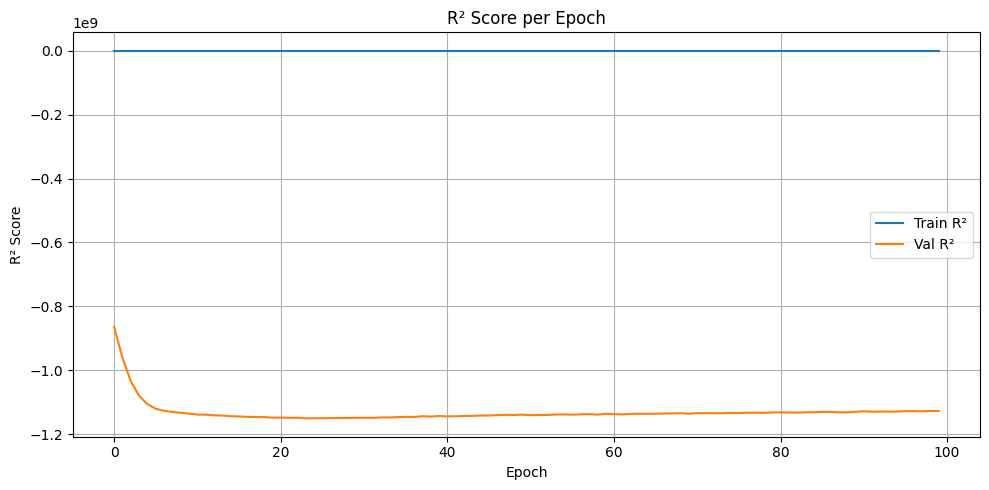

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['r2_score_per_timestep'], label='Train R²')
plt.plot(history.history['val_r2_score_per_timestep'], label='Val R²')
plt.title("R² Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

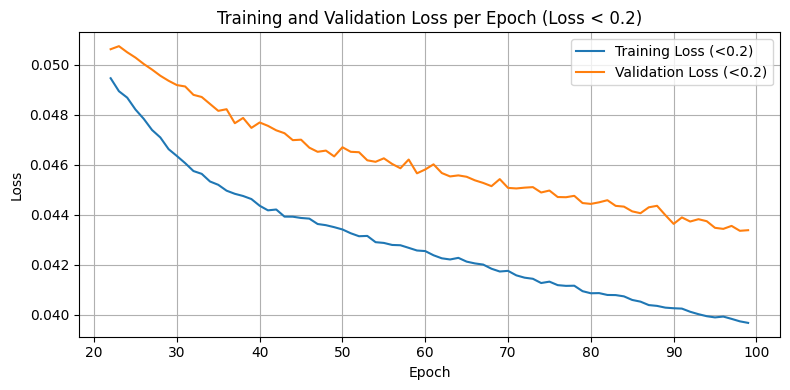

In [133]:
plt.figure(figsize=(8, 4))
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
epochs = np.arange(len(train_loss))

mask = train_loss < 0.05
plt.plot(epochs[mask], train_loss[mask], label='Training Loss (<0.2)')
plt.plot(epochs[mask], val_loss[mask], label='Validation Loss (<0.2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch (Loss < 0.2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



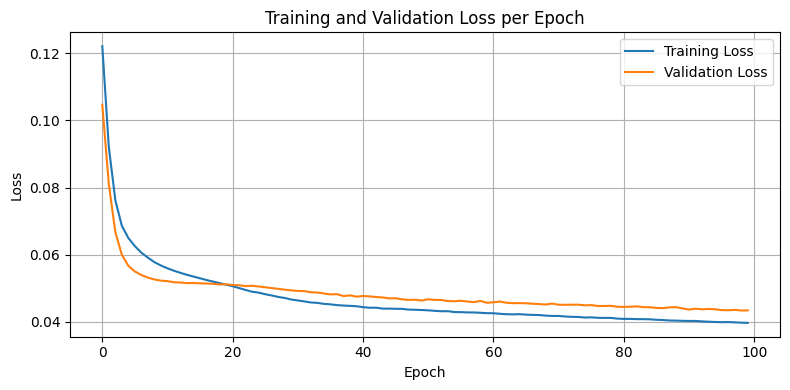

In [134]:
plt.figure(figsize=(8, 4))
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
epochs = np.arange(len(train_loss))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluate the model

In [135]:
loss = model.evaluate(
    {
        'seq_input': X_seq_test,
        'mch_input': X_static_test[:, 2].astype(np.float32),
        'site': X_static_test[:, 0].astype(np.int32),
        'species': X_static_test[:, 1].astype(np.int32),
        'year_input': X_static_test[:, 3].astype(np.int32),
        'day_sin': X_static_test[:, 4].astype(np.float32),
        'day_cos': X_static_test[:, 5].astype(np.float32)
    },
    y_test_with_species
)
print("Test Loss:", loss)


314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0657 - r2_score_per_timestep: -1163124608.0000
Test Loss: [0.052750665694475174, -1218695296.0]


In [136]:
# Flatten the sequence input
sample_size = 20  # can adjust this
# Flatten seq_input (shape: n, seq_len, n_features) → (n, seq_len * n_features)
seq_flat = X_seq_test.reshape((X_seq_test.shape[0], -1))

# Concatenate with static features (site, species, mch)
X_shap = np.concatenate([seq_flat, X_static_test], axis=1).astype(np.float32)


In [137]:
def model_predict(data):
    n_seq_features = X_seq_test.shape[2]
    seq_len = X_seq_test.shape[1]
    
    seq_input = data[:, :seq_len * n_seq_features].reshape((-1, seq_len, n_seq_features))
    site_input = data[:, seq_len * n_seq_features].astype(np.int32).reshape(-1, 1)
    species_input = data[:, seq_len * n_seq_features + 1].astype(np.int32).reshape(-1, 1)
    mch_input = data[:, seq_len * n_seq_features + 2].astype(np.float32).reshape(-1, 1)
    year_input = data[:, seq_len * n_seq_features + 3].astype(np.int32).reshape(-1, 1)
    day_sin_input = data[:, seq_len * n_seq_features + 4].astype(np.float32).reshape(-1, 1)
    day_cos_input = data[:, seq_len * n_seq_features + 5].astype(np.float32).reshape(-1, 1)
    
    # Return only the prediction for day 3, for example
    return model.predict({
        'seq_input': seq_input,
        'mch_input': mch_input,
        'site': site_input,
        'species': species_input,
        'year_input': year_input,
        'day_sin': day_sin_input,
        'day_cos': day_cos_input
    })[:, 0]  # Only the 1st day



In [138]:
print(X_shap.shape)
print(SEQ_LEN == X_seq_test.shape[1])
n_dyn = X_seq_test.shape[2]

dynamic_names = [f"{feat}_t{t}" for t in range(SEQ_LEN) for feat in dynamic_scaled_features]
static_names = ['site_enc', 'species_enc', 'mch_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled']
feature_names = dynamic_names + static_names
print(feature_names)

(10040, 186)
True
['pr_rolling30_scaled_t0', 'at_rolling30_scaled_t0', 'ws_rolling30_scaled_t0', 'dp_rolling30_scaled_t0', 'sr_rolling30_scaled_t0', 'lr_rolling30_scaled_t0', 'pr_rolling30_scaled_t1', 'at_rolling30_scaled_t1', 'ws_rolling30_scaled_t1', 'dp_rolling30_scaled_t1', 'sr_rolling30_scaled_t1', 'lr_rolling30_scaled_t1', 'pr_rolling30_scaled_t2', 'at_rolling30_scaled_t2', 'ws_rolling30_scaled_t2', 'dp_rolling30_scaled_t2', 'sr_rolling30_scaled_t2', 'lr_rolling30_scaled_t2', 'pr_rolling30_scaled_t3', 'at_rolling30_scaled_t3', 'ws_rolling30_scaled_t3', 'dp_rolling30_scaled_t3', 'sr_rolling30_scaled_t3', 'lr_rolling30_scaled_t3', 'pr_rolling30_scaled_t4', 'at_rolling30_scaled_t4', 'ws_rolling30_scaled_t4', 'dp_rolling30_scaled_t4', 'sr_rolling30_scaled_t4', 'lr_rolling30_scaled_t4', 'pr_rolling30_scaled_t5', 'at_rolling30_scaled_t5', 'ws_rolling30_scaled_t5', 'dp_rolling30_scaled_t5', 'sr_rolling30_scaled_t5', 'lr_rolling30_scaled_t5', 'pr_rolling30_scaled_t6', 'at_rolling30_scale

 background = X_shap[:20]: A sample of representative input data used by SHAP to estimate the baseline prediction (i.e., what the model would predict in the absence of specific feature values. You're telling SHAP to use the first 20 samples from your input data as the background set for reference.

In [139]:
# background = X_shap[:20]
background = X_shap[np.random.choice(len(X_shap), 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)
#shap_values = explainer.shap_values(X_shap[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step


In [ ]:
# === Compute SHAP values ===
# If your model outputs 7 values (7-day forecast), specify ranked_outputs=1 to pick the most important one
# Make sure your input is shaped (samples, features), not (features, samples)
nb_samples_shap = 40

# Randomly select nb_samples_shap indices
indices = np.random.choice(len(X_shap), nb_samples_shap, replace=False)
X_shap_subset = X_shap[indices]

shap_values = explainer.shap_values(X_shap_subset) # shape: (5, 183)
print(shap_values.shape)

  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 72s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 72s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 72s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 73s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
6694/6694 ━━━━━━━━━━━━━━━━━━━━ 71s 11

C:\Users\salom\AppData\Local\Temp\ipykernel_27476\2506614996.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)


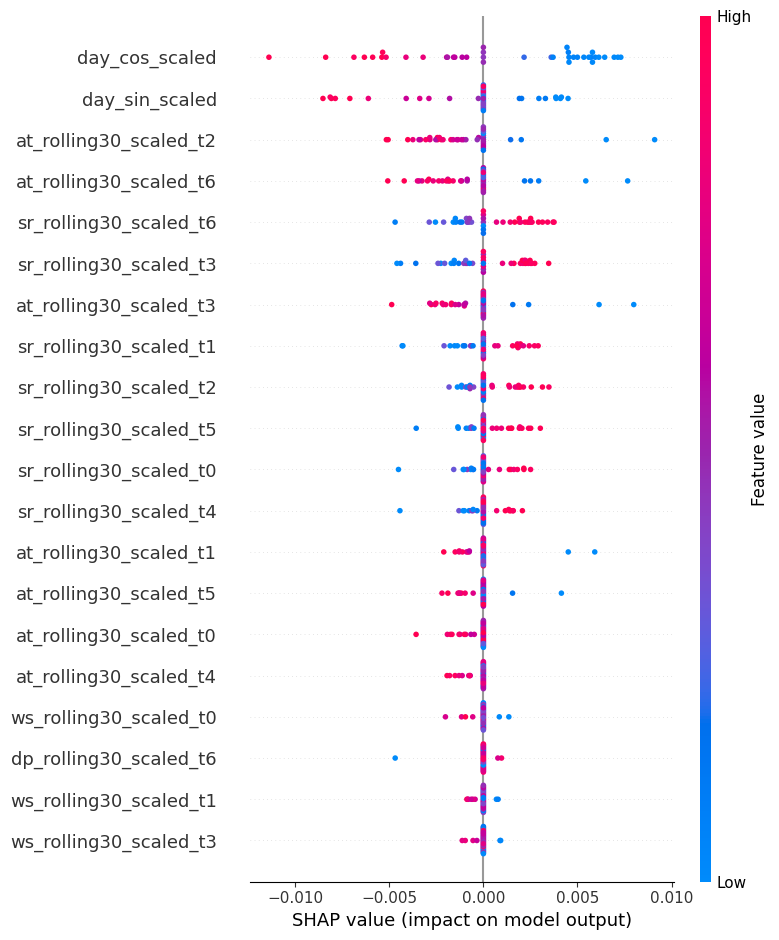

In [ ]:
shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)

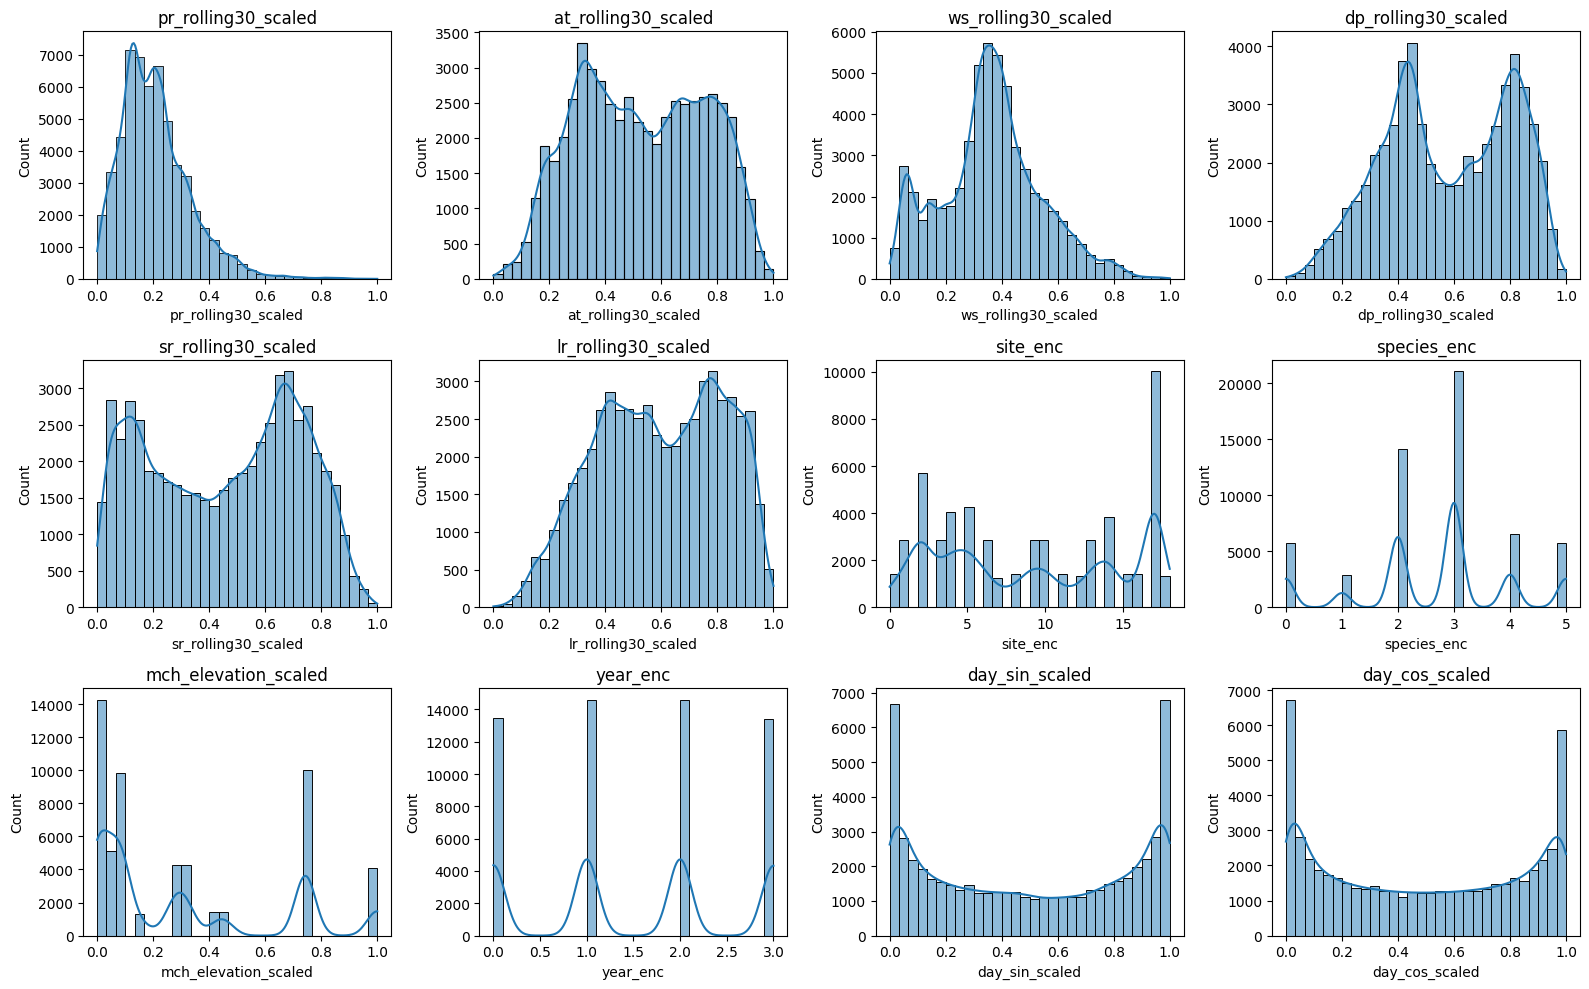

In [140]:
# Plot the distribution of each input variable (scaled dynamic and static features)

input_vars = dynamic_scaled_features + static_scaled_features
plt.figure(figsize=(16, 10))
for i, col in enumerate(input_vars):
    plt.subplot(3, int(np.ceil(len(input_vars)/3)), i+1)
    sns.histplot(df_ts_series[col], kde=True, bins=30)
    plt.title(col)
    plt.tight_layout()
plt.show()

In [141]:
site_enc_idx = feature_names.index('site_enc')

# Print unique values of site_enc in X_shap_subset
print("Unique site_enc in X_shap_subset:", np.unique(X_shap_subset[:, site_enc_idx]))

# To get the corresponding site names, map site_enc back to site using the label encoder
unique_site_encs = np.unique(X_shap_subset[:, site_enc_idx]).astype(int)
unique_sites = le_site.inverse_transform(unique_site_encs)
print("Corresponding site names:", unique_sites)

# Assume shap_values shape: (nb_samples_shap, n_features)
# Find the index of 'site_enc' in your feature_names
site_idx = feature_names.index('site_enc')

# Get the site_enc values for your SHAP sample
site_enc_values = X_shap_subset[:, site_idx]
print("Site Enc Values:", site_enc_values)
site_shap = shap_values[:, site_idx]

# Create a DataFrame for easy grouping
df_site = pd.DataFrame({
    'site_enc': site_enc_values,
    'shap': site_shap
})

# Calculate mean absolute SHAP value per site
site_shap_mean = df_site.groupby('site_enc')['shap'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

plt.figure(figsize=(10,5))
site_shap_mean.plot(kind='bar')
plt.title('Mean |SHAP value| per site_enc')
plt.xlabel('site_enc')
plt.ylabel('Mean |SHAP value|')
plt.show()

NameError: name 'X_shap_subset' is not defined

In [ ]:
print("Unique site_enc in X_static_test:", np.unique(X_static_test[:, 0]))
print("Unique site_enc in X_shap:", np.unique(X_shap[:, site_idx]))

Unique site_enc in X_static_test: [np.int64(0) np.int64(1) np.int64(2) np.int64(3) np.int64(4) np.int64(5)
 np.int64(6) np.int64(7) np.int64(8) np.int64(9) np.int64(10) np.int64(11)
 np.int64(12) np.int64(13) np.int64(14) np.int64(15) np.int64(16)
 np.int64(17) np.int64(18)]


NameError: name 'site_idx' is not defined

In [ ]:
site_enc_values = X_shap[:nb_samples_shap, site_idx]
site_enc_values

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
print("First few target values:", y_train[:10, 0])
print(np.mean(y_train[:, 0]), np.std(y_train[:, 0]))

First few target values: [0.22566167 0.22786615 0.22906656 0.230613   0.24073165 0.24025773
 0.2393379  0.23666135 0.22865427 0.21677019]
0.25147668146267865 0.19250426238925505


In [142]:
y_pred = model.predict({
    'seq_input': X_seq_test.astype(np.float32),
    'mch_input': X_static_test[:, 2].astype(np.float32).reshape(-1, 1),
    'site': X_static_test[:, 0].astype(np.int32).reshape(-1, 1),
    'species': X_static_test[:, 1].astype(np.int32).reshape(-1, 1),
    'year_input': X_static_test[:, 3].astype(np.int32).reshape(-1, 1),
    'day_sin': X_static_test[:, 4].astype(np.float32).reshape(-1, 1),
    'day_cos': X_static_test[:, 5].astype(np.float32).reshape(-1, 1)
})
# Unscale predictions
y_pred_unscaled = scalers[target_column].inverse_transform(y_pred)
y_pred_original = np.expm1(y_pred_unscaled) #  Inverse log1p

314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [143]:
y_pred_original

array([[0.17089315],
       [0.17168231],
       [0.17151012],
       ...,
       [0.20751685],
       [0.21348794],
       [0.21956086]], dtype=float32)

In [144]:
y_test_unscaled = scalers[target_column].inverse_transform(y_test)
# Inverse log1p to get original units
y_test_original = np.expm1(y_test_unscaled)

In [145]:
print("y_pred shape:", y_pred.shape) # Number of sequences
print("Total predicted values:", y_pred.shape[0] * y_pred.shape[1])

y_pred shape: (10040, 1)
Total predicted values: 10040


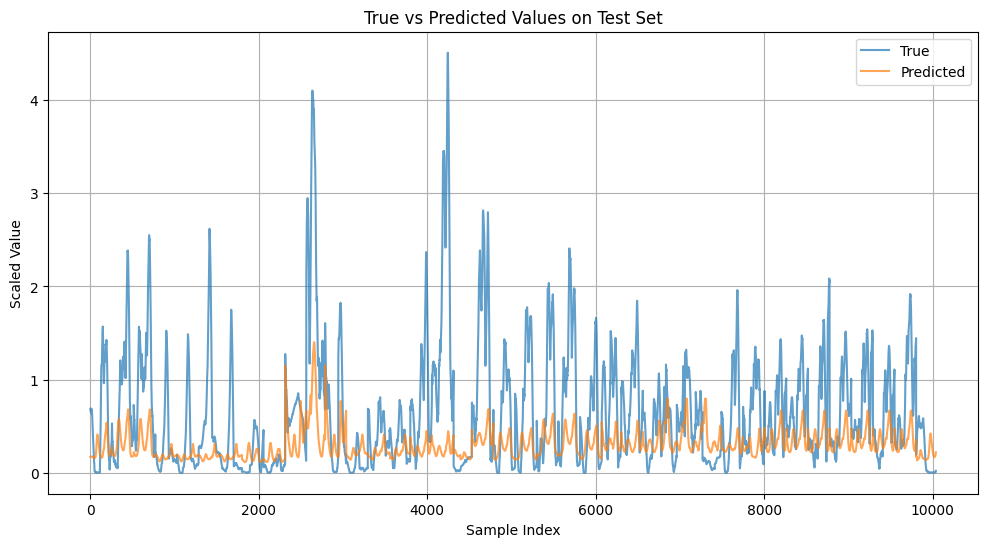

In [146]:
# Plot true vs predicted

plt.figure(figsize=(12, 6))
plt.plot(y_test_original[:, 0], label='True', alpha=0.7)
plt.plot(y_pred_original[:, 0], label='Predicted', alpha=0.7)
plt.title('True vs Predicted Values on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

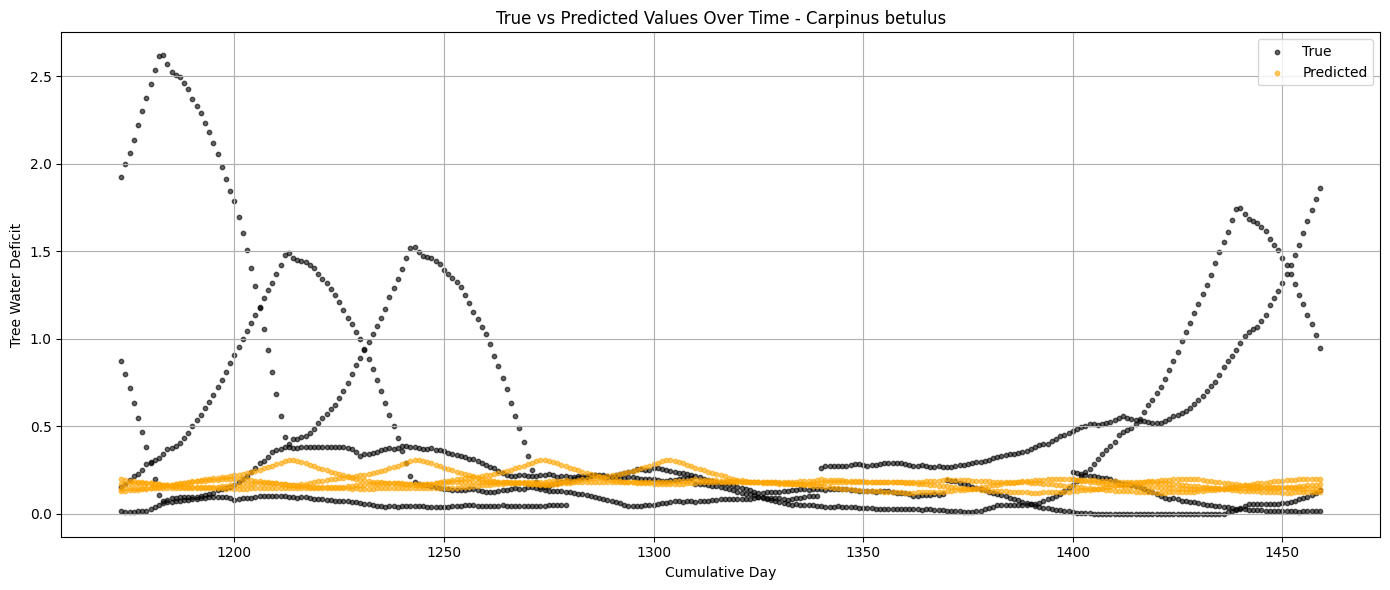

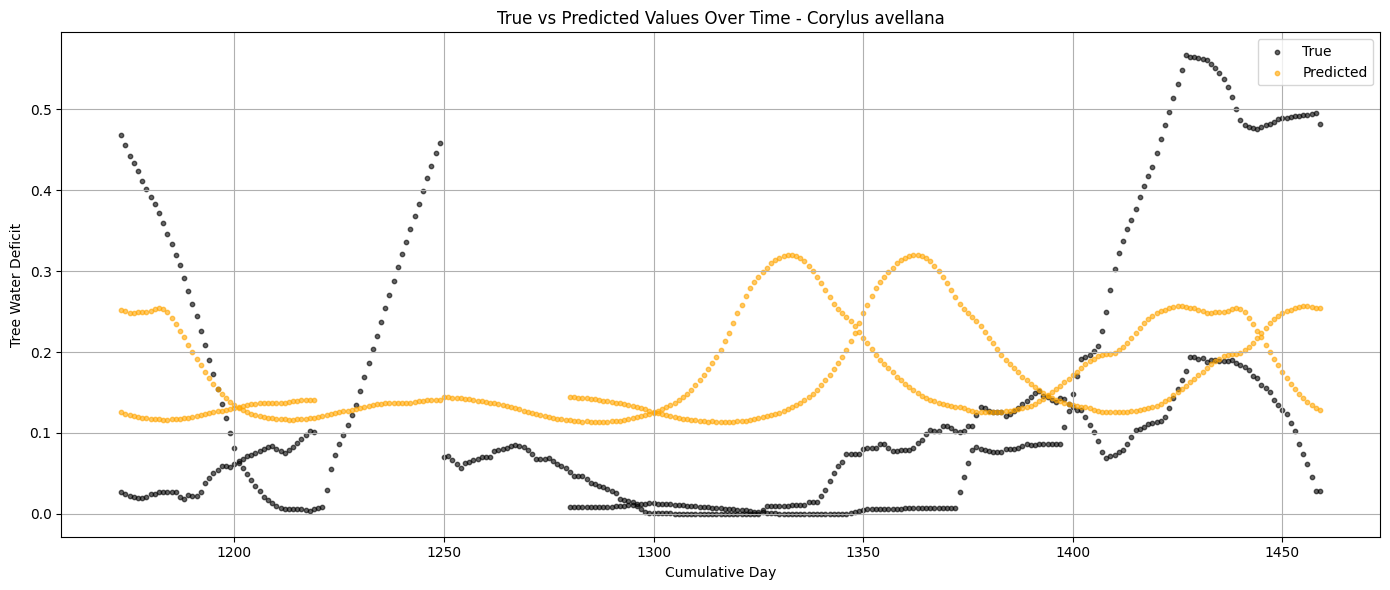

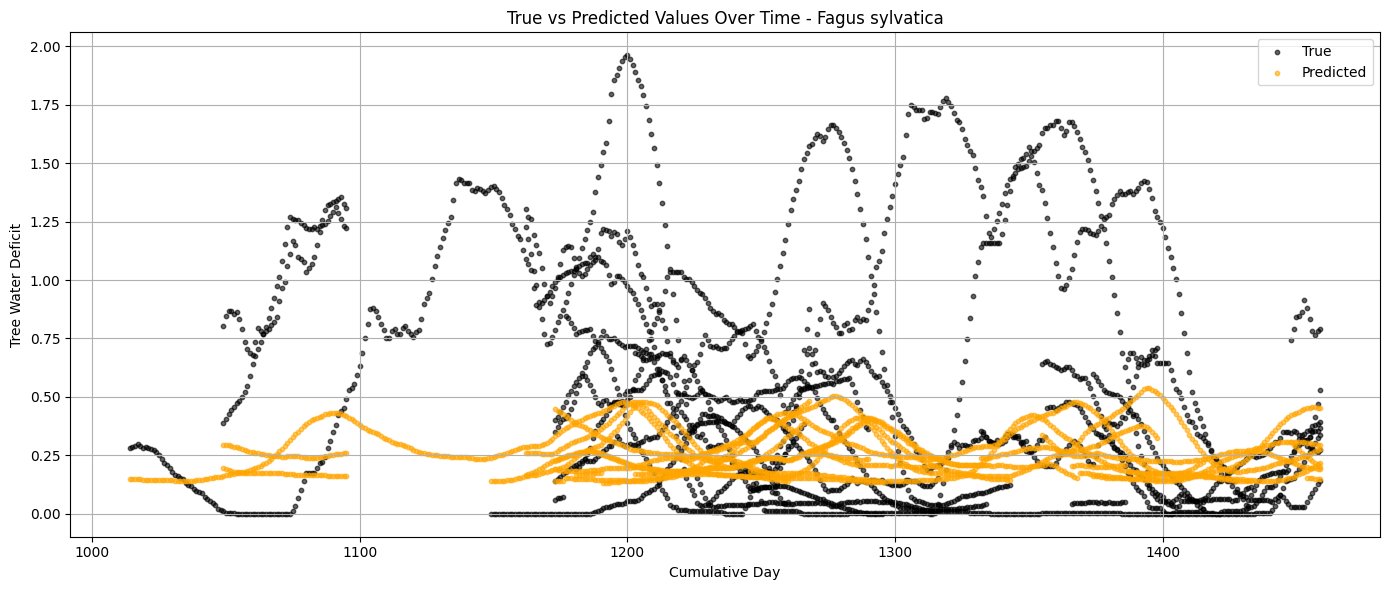

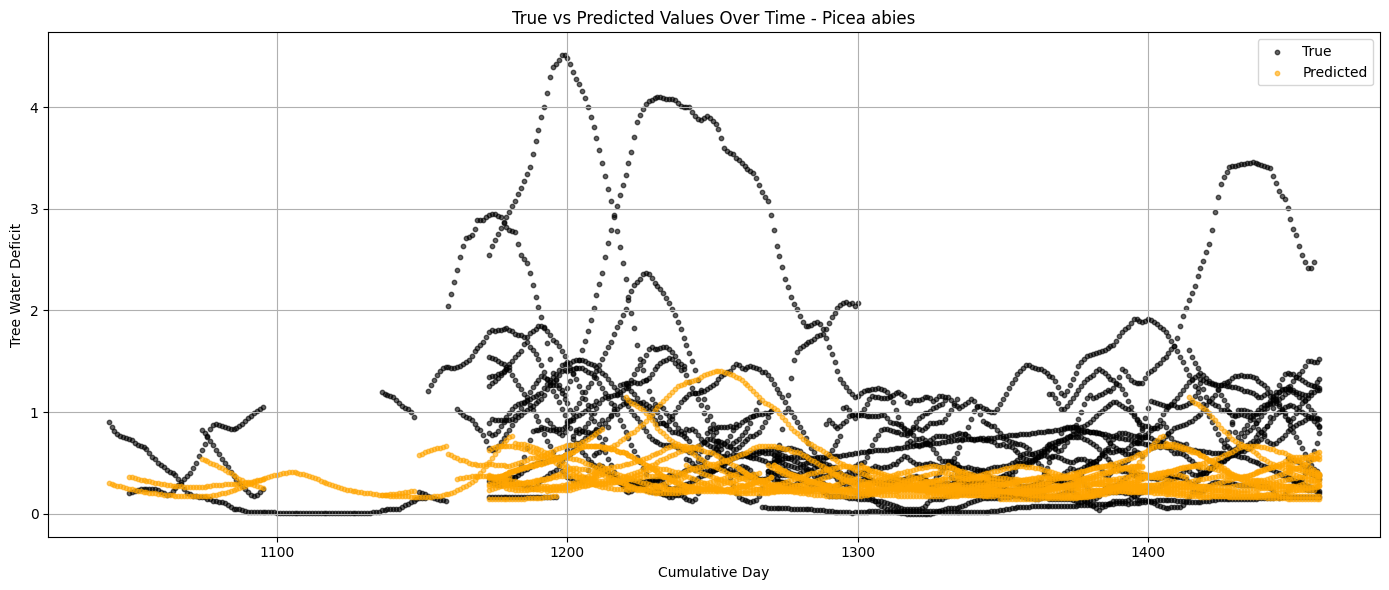

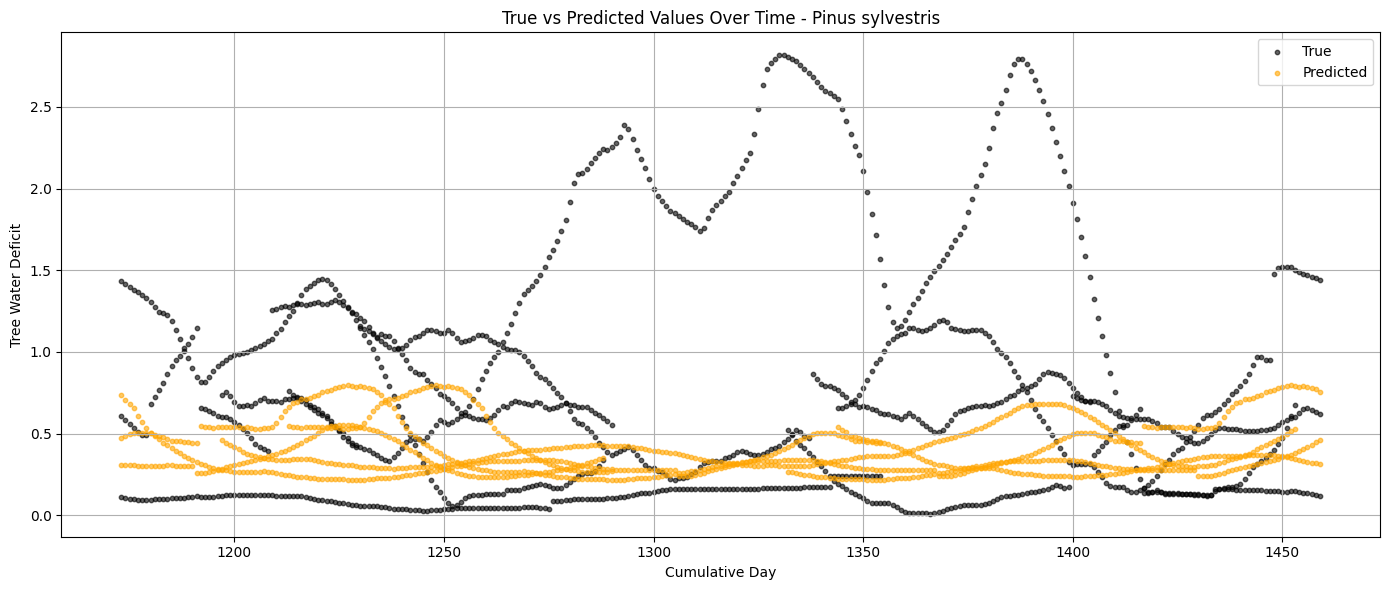

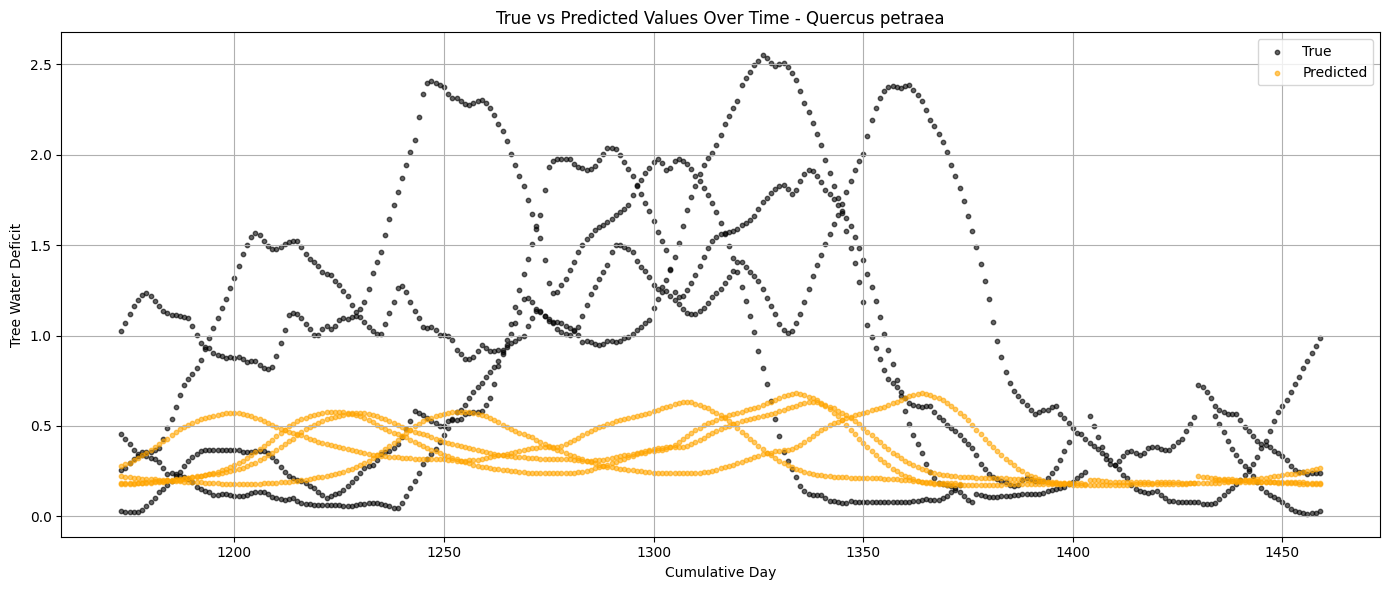

In [147]:
species_names = le_species.inverse_transform(np.unique(X_static_test[:, 1].astype(int)))
species_codes = np.unique(X_static_test[:, 1].astype(int))

cum_days = df_test['cum.time.days'].iloc[SEQ_LEN:SEQ_LEN+len(y_test)].values

for code, name in zip(species_codes, species_names):
    mask = X_static_test[:, 1].astype(int) == code
    plt.figure(figsize=(14, 6))
    plt.scatter(cum_days[mask], y_test_original[mask, 0], label='True', color='black', alpha=0.6, s=10)
    plt.scatter(cum_days[mask], y_pred_original[mask, 0], label='Predicted', color='orange', alpha=0.6, s=10)
    plt.xlabel('Cumulative Day')
    plt.ylabel('Tree Water Deficit')
    plt.title(f'True vs Predicted Values Over Time - {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [148]:
y_test.shape

(10040, 1)

In [ ]:
print(future_dates)
print(pred_unscaled)